# 03 — Comments / Amazon Review Sentiment Neural Network

**INTELLIGENT SYSTEM DEVELOPMENT — ASSIGNMENT 03: NEURAL NETWORKS AND REPRESENTATION LEARNING**

Notebook giải bài toán **phân loại cảm xúc Amazon Review** với hai lớp Negative/Positive. Nguồn dữ liệu gồm `train.csv` khoảng 3,6 triệu review và official `test.csv` khoảng 400 nghìn review; thí nghiệm FULL dùng tập con tái lập gồm 800.000 train, 100.000 validation và 200.000 official test.

Hai loại representation phải được phân biệt: TF-IDF 20.000 chiều là prepared representation do thuật toán vector hóa tạo ra; activation ẩn `hθ(x)` của MLP là learned representation được tối ưu qua backpropagation. Ba sparse baseline được so sánh công bằng với ba cấu hình MLP trên cùng thiết kế dữ liệu.

> Notebook đã được chạy FULL và lưu output. Phần diễn giải dưới đây dựa trực tiếp trên code, bảng và figure đã lưu; không tái huấn luyện hay làm đẹp kết quả.

## Nguyên tắc train / validation / test và kiểm soát rò rỉ dữ liệu

Official train cung cấp train pool, sau đó được stratified split thành train và validation. Official test được lấy riêng từ `test.csv`. Train dùng để fit TF-IDF và model; validation chọn kiến trúc, learning rate và checkpoint; test chỉ đánh giá cấu hình đã khóa.

Vocabulary và IDF chỉ được học từ 800.000 training review. Validation/test chỉ `transform`; nếu fit vectorizer trên cả ba tập, tần suất token ngoài train sẽ chảy vào representation và gây leakage. Random seed 42 giúp tái lập sampling/split trong cùng môi trường nhưng không bảo đảm bitwise-identical trên mọi hệ thống.

## Quy mô và chi phí tính toán

File train khoảng 1,58 GB, test khoảng 176 MB. Pipeline quét CSV theo chunk 100.000 dòng rồi giữ tập con có kiểm soát, thay vì huấn luyện trên toàn bộ khoảng 4 triệu review. Tất cả mô hình dùng cùng 800K/100K/200K samples nên comparison vẫn nhất quán trong phạm vi subset.

TF-IDF train có shape `800.000×20.000`. Nếu densify toàn bộ thành float32 sẽ cần khoảng **64 GB** theo hệ thập phân chỉ cho feature matrix; implementation giữ CSR sparse và chỉ dense từng batch 256×20.000, thực tế **19,53125 MiB**. Ba MLP chạy tổng khoảng 56,5 phút trên CPU, phù hợp với mạng nông, sparse storage và batch-wise vectorization; runtime dưới một giờ không phải dấu hiệu chạy thiếu.

### Thư viện và tiện ích lưu figure

Cell nạp pandas/NumPy, scikit-learn, PyTorch và plotting. `save_figure` chỉ ghi figure ở FULL mode; cell chưa đọc dữ liệu hay huấn luyện. Việc gom import và seed-related utilities ở đầu giúp các bước sau dùng chung một môi trường.

In [1]:
from pathlib import Path
import copy
import json
import random
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from sklearn import metrics
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset

pd.set_option("display.max_columns", 100)
warnings.filterwarnings("ignore", category=FutureWarning)

def save_figure(output_path, *args, **kwargs):
    """Không ghi figure QUICK_MODE vào thư mục kết quả final."""
    if QUICK_MODE:
        print(f"QUICK_MODE: không lưu figure final {output_path}")
        return
    plt.savefig(output_path, *args, **kwargs)


### Trạng thái khởi tạo

Cell chạy không lỗi, nên các dependency cần cho CSV, sparse TF-IDF, baseline, MLP và visualization đã sẵn sàng. Không có metric nào được sinh ở bước này.

### Cấu hình thí nghiệm FULL

Cell cố định `RANDOM_STATE=42`, khai báo data path, sample limits, TF-IDF, batch và early stopping. Lần chạy đã lưu dùng `QUICK_MODE=False`, 800K train, 100K validation, 200K test, vocabulary tối đa 20K, batch 256, tối đa 15 epoch và patience 4. Hai optional flag đều tắt.

In [2]:
RANDOM_STATE = 42
QUICK_MODE = False
RUN_OPTIONAL_DIAGNOSTICS = False
RUN_SEED_STABILITY = False

DATA_RELATIVE_PATH = Path("data/ecommerce/train.csv")
TEST_RELATIVE_PATH = Path("data/ecommerce/test.csv")
COMMENTS_TRAIN_LIMIT = 800_000 if not QUICK_MODE else 4_000
COMMENTS_VAL_LIMIT = 100_000 if not QUICK_MODE else 1_000
COMMENTS_TEST_LIMIT = 200_000 if not QUICK_MODE else 5_000
EXPECTED_TRAIN_ROWS = 3_600_000
EXPECTED_TEST_ROWS = 400_000
CHUNK_SIZE = 100_000
TFIDF_MAX_FEATURES = 20_000
TFIDF_MIN_DF = 5 if not QUICK_MODE else 2
BATCH_SIZE = 256 if not QUICK_MODE else 64
EPOCHS = 15 if not QUICK_MODE else 2
PATIENCE = 4 if not QUICK_MODE else 2
NUM_WORKERS = 0

def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def find_repo_root(relative_data_path):
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / relative_data_path).exists():
            return candidate
    raise FileNotFoundError(f"Không tìm thấy {relative_data_path} từ {start}")

set_seed()
REPO_ROOT = find_repo_root(DATA_RELATIVE_PATH)
DATA_PATH = REPO_ROOT / DATA_RELATIVE_PATH
MODEL_DIR = REPO_ROOT / "models" / "assignment03" / "comments"
FIGURE_DIR = REPO_ROOT / "figures" / "assignment03" / "comments"
RESULT_DIR = REPO_ROOT / "results" / "assignment03"
for directory in (MODEL_DIR, FIGURE_DIR, RESULT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print({"quick_mode": QUICK_MODE, "data": str(DATA_PATH), "model_dir": str(MODEL_DIR)})

{'quick_mode': False, 'data': 'E:\\WINDOW\\Project\\intelligent-system-assignment-01\\data\\ecommerce\\train.csv', 'model_dir': 'E:\\WINDOW\\Project\\intelligent-system-assignment-01\\models\\assignment03\\comments'}


### Kết quả cấu hình

Output xác nhận FULL mode và đường dẫn đúng `data/ecommerce/train.csv`; artifact model được đặt trong `models/assignment03/comments`. Các metric sau đây vì thế không phải kết quả QUICK_MODE.

### Thiết bị tính toán

Cell chọn CUDA khi khả dụng, ngược lại dùng CPU. Model và từng dense mini-batch luôn được chuyển lên cùng device; đây là điều kiện bắt buộc để forward/backward hợp lệ.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_info = {"device": str(device), "cuda_available": torch.cuda.is_available()}
if torch.cuda.is_available():
    device_info["gpu_name"] = torch.cuda.get_device_name(0)
print(device_info)

{'device': 'cpu', 'cuda_available': False}


### Device thực tế

Output là `device='cpu'`, CUDA không khả dụng. Vì vậy thời gian MLP 17–21 phút mỗi cấu hình là CPU timing của máy chạy notebook, không phải benchmark phổ quát cho kiến trúc.

### Kiểm tra nguồn và schema

Cell đọc năm review đầu bằng CSV parser, kiểm tra train/test có cùng schema và báo kích thước file. Dùng parser thay vì đếm dòng vật lý là cần thiết vì nội dung review có thể chứa newline trong quoted field.

In [4]:
TEST_PATH=REPO_ROOT/TEST_RELATIVE_PATH
train_preview=pd.read_csv(DATA_PATH,nrows=5); test_preview=pd.read_csv(TEST_PATH,nrows=5)
assert {"Review","Label"}.issubset(train_preview.columns) and list(train_preview.columns)==list(test_preview.columns)
print("Train file bytes:",DATA_PATH.stat().st_size,"Test file bytes:",TEST_PATH.stat().st_size); display(train_preview); display(train_preview.dtypes.rename("dtype").to_frame())

Train file bytes: 1581600238 Test file bytes: 175646693


,Review,Label
0,Stuning even for the non-gamer: This sound tra...,2
1,The best soundtrack ever to anything.: I'm rea...,2
2,Amazing!: This soundtrack is my favorite music...,2
3,Excellent Soundtrack: I truly like this soundt...,2
4,"Remember, Pull Your Jaw Off The Floor After He...",2


,dtype
Review,str
Label,int64


### Schema và ý nghĩa nhãn

Hai cột thực tế là `Review` và `Label`; preview cho thấy review dạng chuỗi và label số nguyên. Mapping được dùng xuyên suốt là original label `1→class 0→Negative`, `2→class 1→Positive`. File train có 1.581.600.238 bytes, file test 175.646.693 bytes. Notebook cấu hình quy mô nguồn kỳ vọng lần lượt 3.600.000 và 400.000 records; output không thực hiện một phép đếm records độc lập.

## Tập con tái lập từ file lớn

Hàm sampling không lấy các dòng đầu. Mỗi chunk được hash theo cặp `Review+Label`, XOR seed 42 và chọn theo threshold cố định; sau đó lấy số lượng bằng nhau ở mỗi lớp rồi shuffle tái lập. Official train cung cấp pool 900K để chia 800K/100K, official test cung cấp riêng 200K.

Do sampling chủ động lấy bằng nhau mỗi lớp, balance quan sát được là thuộc tính của **thiết kế thí nghiệm**, không phải bằng chứng raw corpus tự nhiên cân bằng.

### Mapping nhãn, cleaning và hash sampling

`normalize_reviews` chỉ điền chuỗi rỗng cho missing, ép kiểu string, gom whitespace liên tiếp và trim hai đầu. Code không stemming, lemmatization, stopword removal, emoji normalization hay language detection. Cleaning nhẹ giữ lại negation và phần lớn tín hiệu lexical sentiment; review rỗng mới bị loại.

In [5]:
LABEL_MAP={1:0,2:1}; LABEL_NAME={0:"Negative",1:"Positive"}
def normalize_reviews(series):
    return series.fillna("").astype(str).str.replace(r"\s+"," ",regex=True).str.strip()

def reproducible_csv_subset(csv_path, desired_total, expected_rows):
    if QUICK_MODE:
        frame=pd.read_csv(csv_path,nrows=int(np.ceil(desired_total * 1.10)))
    else:
        threshold=np.uint64(min(2**64-1,int((desired_total*1.25/expected_rows)*(2**64-1)))); parts=[]
        for chunk in pd.read_csv(csv_path,chunksize=CHUNK_SIZE):
            hashes=pd.util.hash_pandas_object(chunk[["Review","Label"]],index=False).to_numpy(dtype="uint64") ^ np.uint64(RANDOM_STATE)
            selected=chunk.loc[hashes<=threshold]
            if len(selected): parts.append(selected)
        frame=pd.concat(parts,ignore_index=True)
    frame=frame.dropna(subset=["Label"]).copy(); frame["label"]=frame["Label"].map(LABEL_MAP); frame=frame.dropna(subset=["label"]); frame["label"]=frame["label"].astype("int64"); frame["text"]=normalize_reviews(frame["Review"]); frame=frame.loc[frame.text.str.len()>0]
    per_class=desired_total//2; balanced=pd.concat([group.sample(n=min(per_class,len(group)),random_state=RANDOM_STATE+int(label)) for label,group in frame.groupby("label")],ignore_index=True)
    return balanced.sample(frac=1,random_state=RANDOM_STATE).reset_index(drop=True)

### Chi phí quét CSV

Ở FULL mode, hàm đọc train/test theo chunk 100.000 để tránh giữ toàn bộ khoảng 4 triệu review trong RAM. Threshold lấy dư candidate khoảng 25%, rồi sampling đúng giới hạn theo lớp. Bước này tốn I/O nhưng bộ nhớ chủ yếu dành cho khoảng 1,1 triệu review được chọn.

### Xây dựng train, validation và official test

Cell tạo hai subset từ hai file nguồn độc lập. Pool 900K từ official train được stratified split; official test không tham gia split hoặc tuning. Output báo shape, tỷ lệ nhãn và độ dài review để kiểm chứng dữ liệu thực dùng.

In [6]:
train_pool=reproducible_csv_subset(DATA_PATH,COMMENTS_TRAIN_LIMIT+COMMENTS_VAL_LIMIT,EXPECTED_TRAIN_ROWS)
test_df=reproducible_csv_subset(TEST_PATH,COMMENTS_TEST_LIMIT,EXPECTED_TEST_ROWS)
validation_fraction=COMMENTS_VAL_LIMIT/(COMMENTS_TRAIN_LIMIT+COMMENTS_VAL_LIMIT)
train_df,val_df=train_test_split(train_pool,test_size=validation_fraction,stratify=train_pool.label,random_state=RANDOM_STATE)
train_df=train_df.reset_index(drop=True); val_df=val_df.reset_index(drop=True)
for name,frame in [("train",train_df),("validation",val_df),("official test",test_df)]: print(name,frame.shape,frame.label.value_counts(normalize=True).sort_index().to_dict(),frame.text.str.len().describe()[["mean","50%","max"]].to_dict())

train (800000, 4) {0: 0.5, 1: 0.5} {'mean': 431.58448375, '50%': 383.0, 'max': 1015.0}
validation (100000, 4) {0: 0.5, 1: 0.5} {'mean': 433.23863, '50%': 385.0, 'max': 1015.0}
official test (200000, 4) {0: 0.5, 1: 0.5} {'mean': 431.2426, '50%': 382.0, 'max': 1015.0}


### Kết quả construction

Train có **800.000**, validation **100.000**, official test **200.000** review; mỗi tập đúng 50% Negative và 50% Positive. Độ dài trung bình khoảng 431,6/433,2/431,2 ký tự, median 383/385/382 và max đều 1.015, cho thấy ba tập tương đồng theo thống kê độ dài được báo.

### EDA class và độ dài review

Cell vẽ phân phối nhãn train cùng histogram độ dài theo lớp. Độ dài chỉ được clip ở percentile 99 để hiển thị; text đưa vào TF-IDF không bị cắt.

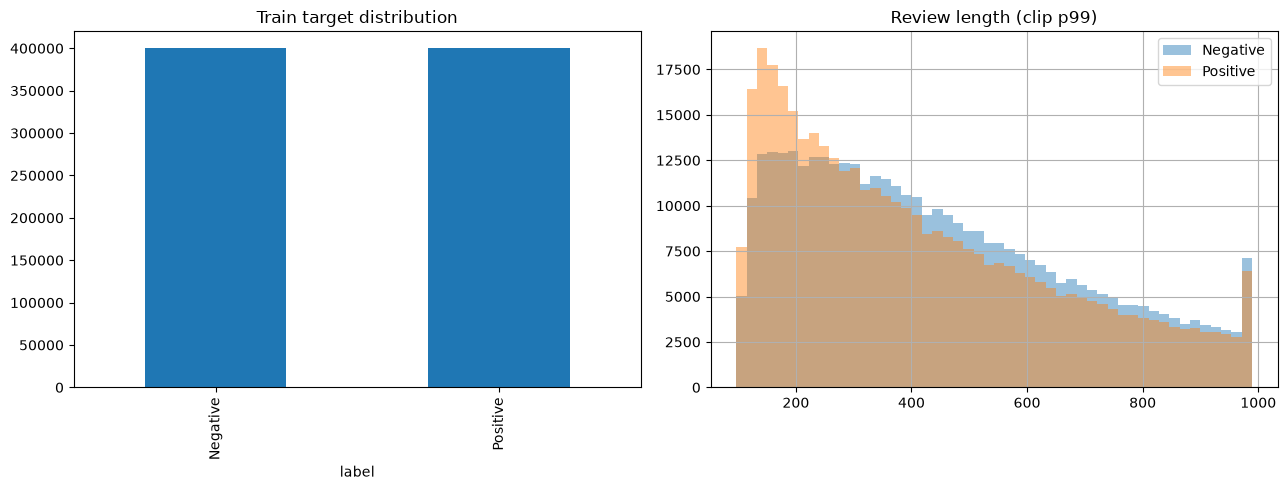

In [7]:
fig,axes=plt.subplots(1,2,figsize=(13,5)); train_df.label.map(LABEL_NAME).value_counts().plot.bar(ax=axes[0],title="Train target distribution");
for label,name in LABEL_NAME.items(): train_df.loc[train_df.label.eq(label),"text"].str.len().clip(upper=train_df.text.str.len().quantile(.99)).hist(bins=50,alpha=.45,label=name,ax=axes[1])
axes[1].legend(); axes[1].set_title("Review length (clip p99)"); plt.tight_layout(); save_figure(FIGURE_DIR/"target_and_length.png",dpi=160,bbox_inches="tight"); plt.show()

### Phân tích figure EDA

Hai cột class đều đúng 400.000 do balanced sampling. Histogram Negative/Positive chồng lấn mạnh trên phần lớn khoảng độ dài; Positive nổi bật hơn ở các review rất ngắn, còn Negative hơi nhiều hơn tại nhiều vùng dài hơn. Đây chỉ là association mô tả, không chứng minh độ dài gây ra sentiment hay đủ để phân loại.

## TF-IDF: prepared input và kiểm soát leakage

`TfidfVectorizer` dùng tối đa 20.000 unigram/bigram, `sublinear_tf=True`, `min_df=5`, float32 và Unicode accent stripping. TF đo mức xuất hiện token/ngram trong review; IDF giảm trọng số cụm xuất hiện phổ biến toàn train và tương đối nhấn mạnh cụm hiếm hơn.

TF-IDF là representation được thiết kế trước, không phải hidden representation học bởi neural network. Vectorizer chỉ fit train; validation/test dùng vocabulary và IDF train để ngăn leakage.

### Chi phí vector hóa

Fit vocabulary trên 800K review và transform tổng 1,1 triệu review là bước lớn. CSR chỉ lưu nonzero values/indices; không được `.toarray()` toàn matrix. Sparse linear models có thể học trực tiếp trên CSR, tạo lợi thế lớn về RAM và tốc độ so với MLP phải dense từng batch.

### Fit TF-IDF train-only

Cell gọi `fit_transform` trên train, `transform` trên validation/test, rồi báo dimension, density và footprint thật. `ngram_range=(1,2)` giúp biểu diễn cả từ đơn lẫn cụm hai từ như các mẫu negation ngắn, nhưng vẫn là bag-of-ngrams và không giữ đầy đủ thứ tự/ngữ cảnh dài.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(max_features=TFIDF_MAX_FEATURES,ngram_range=(1,2),sublinear_tf=True,min_df=TFIDF_MIN_DF,dtype=np.float32,strip_accents="unicode")
X_train=vectorizer.fit_transform(train_df.text); X_val=vectorizer.transform(val_df.text); X_test=vectorizer.transform(test_df.text)
y_train=train_df.label.to_numpy(); y_val=val_df.label.to_numpy(); y_test=test_df.label.to_numpy(); d=X_train.shape[1]
def sparse_mb(matrix): return (matrix.data.nbytes+matrix.indices.nbytes+matrix.indptr.nbytes)/1024**2
print("Shapes:",X_train.shape,X_val.shape,X_test.shape,"vocabulary d:",d); print("Train density:",X_train.nnz/(X_train.shape[0]*X_train.shape[1]),"sparse MB:",sparse_mb(X_train)); display(pd.Series(vectorizer.get_feature_names_out()[:20],name="vocabulary sample"))

Shapes: (800000, 20000) (100000, 20000) (200000, 20000) vocabulary d: 20000
Train density: 0.00411180725 sparse MB: 504.9813575744629


0             00
1         00 for
2            000
3             10
4         10 and
5        10 days
6     10 minutes
7       10 times
8        10 year
9       10 years
10           100
11     100 pages
12          1000
13           101
14            11
15            12
16       12 year
17      12 years
18           120
19            13
Name: vocabulary sample, dtype: str

### Kết quả TF-IDF

Shapes là train **(800.000, 20.000)**, validation **(100.000, 20.000)**, test **(200.000, 20.000)**; vocabulary đạt đúng `d=20.000`. Train density chỉ **0,0041118** (khoảng 0,411%), footprint CSR khoảng **504,98 MiB**.

Nếu dùng dense float32, riêng train sẽ khoảng 64 GB thập phân; sparse representation vì thế là quyết định kỹ thuật thiết yếu. Vocabulary sample chứa cả unigram và bigram, đúng cấu hình, nhưng nội dung vocabulary không được học từ validation/test.

## Ba traditional baseline trên sparse TF-IDF

Logistic Regression và LinearSVC học decision boundary tuyến tính trực tiếp trên 20K TF-IDF features; ComplementNB dùng thống kê token theo lớp. Đây là các baseline mạnh và phù hợp tự nhiên với sparse text, nên MLP không mặc nhiên được kỳ vọng thắng.

### Metric classification

Cell thống nhất Accuracy, Precision, Recall, F1 và ROC-AUC cho positive class. Accuracy đo tỷ lệ đúng tổng thể; Precision hỏi trong các prediction Positive có bao nhiêu đúng; Recall hỏi bắt được bao nhiêu Positive thật; F1 cân bằng Precision/Recall. ROC-AUC đánh giá ranking score qua nhiều threshold, không chỉ nhãn ở threshold hiện tại.

LinearSVC không có probability nên AUC dùng `decision_function`; Logistic/NB dùng probability class 1. Dữ liệu được cân bằng chủ động nên Accuracy có ý nghĩa trực quan, nhưng vẫn cần các metric khác để phát hiện lệch FP/FN.

In [9]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
def classification_metrics(y_true,y_pred,y_score): return {"accuracy":accuracy_score(y_true,y_pred),"precision":precision_score(y_true,y_pred,zero_division=0),"recall":recall_score(y_true,y_pred,zero_division=0),"f1":f1_score(y_true,y_pred,zero_division=0),"roc_auc":roc_auc_score(y_true,y_score) if np.unique(y_true).size == 2 else np.nan if np.unique(y_true).size == 2 else np.nan if np.unique(y_true).size == 2 else np.nan if np.unique(y_true).size == 2 else np.nan if np.unique(y_true).size == 2 else np.nan}
def sklearn_score(model,X): return model.predict_proba(X)[:,1] if hasattr(model,"predict_proba") else model.decision_function(X)

### Chi phí baseline

Ba mô hình nhận trực tiếp CSR `800K×20K`, không densify. Output thực tế cho thấy tất cả fit dưới một phút: LinearSVC 42,21 s, Logistic Regression 19,93 s và ComplementNB 0,376 s — nhanh hơn rất nhiều so với mỗi MLP.

### Huấn luyện và đánh giá validation

Cell fit cả ba trên cùng train sparse, dự đoán validation và đo wall-clock training time. Validation được dùng cho comparison; official test chưa tham gia bước này.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
baseline_models={"Logistic Regression":LogisticRegression(max_iter=300,C=2.0,random_state=RANDOM_STATE,n_jobs=-1),"LinearSVC":LinearSVC(C=1.0,random_state=RANDOM_STATE),"ComplementNB":ComplementNB(alpha=.5)}
rows=[]
for name,model in baseline_models.items():
    started=time.perf_counter(); model.fit(X_train,y_train); elapsed=time.perf_counter()-started; pred=model.predict(X_val)
    rows.append({"model":name,"split":"validation",**classification_metrics(y_val,pred,sklearn_score(model,X_val)),"training_seconds":elapsed,"parameter_count":np.nan})
baseline_val_results=pd.DataFrame(rows); display(baseline_val_results.sort_values("f1",ascending=False))

,model,split,accuracy,precision,recall,f1,roc_auc,training_seconds,parameter_count
1,LinearSVC,validation,0.93129,0.932284,0.93014,0.931211,0.979861,42.209417,NaN
0,Logistic Regression,validation,0.93090,0.932804,0.92870,0.930748,0.979711,19.932224,NaN
2,ComplementNB,validation,0.88740,0.890713,0.88316,0.886921,0.955692,0.376000,NaN


### Kết quả traditional validation

**LinearSVC** tốt nhất: Accuracy 0,93129; Precision 0,93228; Recall 0,93014; F1 **0,931211**; AUC **0,979861**; 42,21 s. Logistic Regression rất sát: F1 0,930748, AUC 0,979711, chỉ 19,93 s. ComplementNB nhanh nhất 0,376 s nhưng F1 0,886921 và AUC 0,955692 thấp hơn rõ.

Precision/Recall gần nhau phù hợp với tập cân bằng và không cho thấy thiên lệch class lớn. LinearSVC chỉ hơn Logistic khoảng 0,046 điểm phần trăm F1 nhưng tốn hơn gấp đôi thời gian; đây là trade-off nhỏ về chất lượng đổi lấy chi phí.

## Sparse Dataset / DataLoader

PyTorch `Dataset` chỉ trả row index. `collate_fn` dùng cả danh sách index để slice CSR rồi `.toarray()` đúng mini-batch; full matrix không bao giờ trở thành dense tensor.

### Dense hóa theo batch

Input là sparse matrix cùng label int64. Mỗi batch được chuyển thành float32 tensor để Linear layer xử lý; target giữ `torch.long` cho CrossEntropyLoss. Train loader shuffle, còn train-eval/validation/test giữ thứ tự.

In [11]:
class SparseIndexDataset(Dataset):
    def __init__(self,n_rows): self.n_rows=n_rows
    def __len__(self): return self.n_rows
    def __getitem__(self,index): return index

def make_sparse_loader(matrix,labels,shuffle):
    labels=np.asarray(labels,dtype=np.int64)
    def collate(indices):
        idx=np.asarray(indices,dtype=np.int64); X_batch=matrix[idx].toarray().astype(np.float32,copy=False); return torch.from_numpy(X_batch),torch.from_numpy(labels[idx])
    return DataLoader(SparseIndexDataset(matrix.shape[0]),batch_size=BATCH_SIZE,shuffle=shuffle,num_workers=NUM_WORKERS,collate_fn=collate,pin_memory=torch.cuda.is_available())
train_loader=make_sparse_loader(X_train,y_train,True); train_eval_loader=make_sparse_loader(X_train,y_train,False); val_loader=make_sparse_loader(X_val,y_val,False); test_loader=make_sparse_loader(X_test,y_test,False)
X_batch,y_batch=next(iter(train_loader)); print("Batch:",X_batch.shape,y_batch.shape,"dense batch MB:",X_batch.nelement()*X_batch.element_size()/1024**2)

Batch: torch.Size([256, 20000]) torch.Size([256]) dense batch MB: 19.53125


### Batch thực tế

Output là `X_batch=[256, 20000]`, `y_batch=[256]`. 256 là số samples trong batch; 20.000 là feature dimension, không phải số review. Dense batch tạm thời chiếm **19,53125 MiB**, so với khoảng 64 GB nếu densify toàn train. Tăng batch size sẽ tăng RAM tuyến tính theo `B×d`.

## Từ TF-IDF đến learned representation

Pipeline truyền thống là `review → sparse TF-IDF x → classifier`. Pipeline A03 là `review → TF-IDF x → hidden hθ(x) → logits z`. TF-IDF vẫn là prepared input; `hθ(x)` là learned representation vì weights tạo ra nó được cập nhật nhằm giảm classification loss.

Baseline thực hiện `20000→64→2`: `X∈R^(B×20000)`, `H1∈R^(B×64)`, logits `Z∈R^(B×2)`. Mạng sâu là `20000→64→32→2`, thêm `H2∈R^(B×32)`. ReLU dùng `max(0,z)`; nếu không có phi tuyến, nhiều Linear layer liên tiếp vẫn gộp thành một affine mapping.

### Logits và CrossEntropyLoss

Output `[B,2]` là hai raw logits, chưa phải probability. `nn.CrossEntropyLoss` nhận trực tiếp logits và target `torch.long` shape `[B]`, nội bộ kết hợp log-softmax với negative log-likelihood; không đặt softmax trong forward. Softmax chỉ được dùng lúc evaluation để lấy positive score cho ROC-AUC.

### Training loop và backpropagation

Mỗi batch chạy `model.train() → zero_grad → forward → loss → backward → optimizer.step`. `loss.backward()` dùng autograd và chain rule để tính gradient theo mọi parameter; Adam dùng gradient đó để cập nhật weights theo learning rate.

Validation dùng `model.eval()` và `torch.no_grad()`: lệnh đầu đặt evaluation mode, lệnh sau không dựng graph nên tiết kiệm bộ nhớ. Early stopping theo validation loss, lưu best state và dừng sau bốn epoch không cải thiện. Selection giữa các cấu hình sau đó dùng validation F1 rồi loss; hai tiêu chí này có thể chọn epoch/model khác nhau.

### Định nghĩa MLP và hidden output

Cell xây mạng từ `hidden_dims`, chèn ReLU sau mỗi hidden Linear và để output Linear không activation. `return_hidden=True` trả activation của hidden layer cuối để PCA/linear probe mà không thay đổi prediction path.

In [12]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        previous = input_dim
        for width in hidden_dims:
            layers.extend([nn.Linear(previous, width), nn.ReLU()])
            previous = width
        layers.append(nn.Linear(previous, output_dim))
        self.network = nn.Sequential(*layers)
        self.hidden_dims = tuple(hidden_dims)

    def forward(self, x, return_hidden=False):
        hidden = x
        hidden_states = []
        for layer in self.network[:-1]:
            hidden = layer(hidden)
            if isinstance(layer, nn.ReLU):
                hidden_states.append(hidden)
        output = self.network[-1](hidden)
        return (output, hidden_states[-1]) if return_hidden else output

def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

def architecture_summary(model, input_dim, output_dim):
    return {
        "input_dim": input_dim,
        "hidden_dims": model.hidden_dims,
        "output_dim": output_dim,
        "trainable_parameters": count_trainable_parameters(model),
        "model": str(model),
    }

### Parameter count thực tế

Baseline có `(20000×64+64)+(64×2+2)=1.280.194` trainable parameters. Mạng sâu có `(20000×64+64)+(64×32+32)+(32×2+2)=1.282.210`.

Mạng sâu chỉ thêm 2.016 parameters vì layer `20000→64` đã chiếm hơn 1,28 triệu. Comments MLP lớn hơn nhiều về parameter so với các notebook tabular chủ yếu do `d=20.000`, không phải vì mạng có nhiều tầng.

### Hàm train/evaluate MLP

Cell triển khai metric, loss trung bình, probability cho AUC, history theo epoch và early stopping. Các assertions kiểm tra float32 input, long target, logits `[B,2]` và device nhất quán; chúng giúp phát hiện sai shape/type trước khi âm thầm làm hỏng training.

In [13]:
def evaluate_mlp_classifier(model,loader,criterion):
    model.eval(); losses=[]; labels=[]; predictions=[]; scores=[]
    with torch.no_grad():
        for X_b,y_b in loader:
            X_b,y_b=X_b.to(device),y_b.to(device); logits=model(X_b); losses.append(criterion(logits,y_b).item()*len(y_b)); labels.extend(y_b.cpu().numpy()); predictions.extend(logits.argmax(1).cpu().numpy()); scores.extend(torch.softmax(logits,1)[:,1].cpu().numpy())
    result=classification_metrics(np.asarray(labels),np.asarray(predictions),np.asarray(scores)); result["loss"]=sum(losses)/len(labels); return result

def train_mlp_classifier(config):
    model=MLP(d,config["hidden_dims"],2).to(device); criterion=nn.CrossEntropyLoss(); optimizer=torch.optim.Adam(model.parameters(),lr=config["learning_rate"]); best_state=copy.deepcopy(model.state_dict()); best_loss=float("inf"); best_epoch=0; wait=0; history=[]; started=time.perf_counter()
    for epoch in range(1,config["epochs"]+1):
        model.train(); total=seen=0; train_true=[]; train_pred=[]
        for X_b,y_b in train_loader:
            X_b,y_b=X_b.to(device),y_b.to(device); optimizer.zero_grad(); logits=model(X_b); assert X_b.dtype == torch.float32 and y_b.dtype == torch.long; assert logits.ndim == 2 and logits.shape == (y_b.shape[0],2); assert logits.device == X_b.device == next(model.parameters()).device; loss=criterion(logits,y_b); loss.backward(); optimizer.step(); total+=loss.item()*len(y_b); seen+=len(y_b); train_true.extend(y_b.cpu().numpy()); train_pred.extend(logits.argmax(1).detach().cpu().numpy())
        val=evaluate_mlp_classifier(model,val_loader,criterion); history.append({"epoch":epoch,"train_loss":total/seen,"val_loss":val["loss"],"train_f1":f1_score(train_true,train_pred),"val_f1":val["f1"],"val_accuracy":val["accuracy"]})
        if val["loss"]<best_loss: best_state=copy.deepcopy(model.state_dict()); best_loss=val["loss"]; best_epoch=epoch; wait=0
        else:
            wait+=1
            if wait>=config["patience"]: break
    model.load_state_dict(best_state); elapsed=time.perf_counter()-started; return model,pd.DataFrame(history),{"best_epoch":best_epoch,"training_seconds":elapsed,**evaluate_mlp_classifier(model,val_loader,criterion)}

### Scale và cách đánh giá

Training tối ưu CrossEntropyLoss; bảng báo Accuracy/Precision/Recall/F1/AUC trên validation. `argmax` tạo predicted class, còn softmax class 1 tạo ranking score. F1 là tiêu chí chọn cấu hình chính, loss chỉ phá hòa.

## Ba thí nghiệm MLP bắt buộc

Baseline dùng `[64]`, Adam `1e-3`; mạng sâu `[64,32]`, Adam `1e-3`; optimization experiment giữ nguyên mạng sâu và chỉ giảm learning rate xuống `3e-4`. Nhờ giữ kiến trúc/dữ liệu cố định, khác biệt giữa hai mạng sâu dễ quy cho learning rate hơn so sánh thay đồng thời nhiều yếu tố.

### Chi phí MLP

Mỗi epoch xử lý 800K review qua layer đầu hơn 1,28 triệu weights; sparse input phải dense từng batch. Thời gian đã lưu là 1.069,3 s, 1.070,9 s và 1.252,3 s — tổng khoảng 56,5 phút trên CPU. Early stopping khiến thực tế chỉ chạy 7/6/9 epoch, không phải toàn bộ 15.

### Chạy thí nghiệm và lưu metadata

Cell reset cùng seed cho từng cấu hình, train bằng validation loss, rồi báo architecture, learning rate, batch size, parameter count, best epoch, time và đầy đủ metric validation. Test chưa được xem.

In [14]:
experiment_configs=[{"name":"Baseline MLP","hidden_dims":[64],"learning_rate":1e-3,"epochs":EPOCHS,"patience":PATIENCE},{"name":"Deeper MLP / Adam 1e-3","hidden_dims":[64,32],"learning_rate":1e-3,"epochs":EPOCHS,"patience":PATIENCE},{"name":"Deeper MLP / Adam 3e-4","hidden_dims":[64,32],"learning_rate":3e-4,"epochs":EPOCHS,"patience":PATIENCE}]
mlp_models={}; mlp_histories={}; rows=[]
for config in experiment_configs:
    set_seed(); model,history,result=train_mlp_classifier(config); mlp_models[config["name"]]=model; mlp_histories[config["name"]]=history
    rows.append({"experiment":config["name"],"architecture":f"{d}→"+"→".join(map(str,config["hidden_dims"]))+"→2","input_dim":d,"output_dim":2,"hidden_dims":str(config["hidden_dims"]),"optimizer":"Adam","learning_rate":config["learning_rate"],"batch_size":BATCH_SIZE,"max_epochs":EPOCHS,"early_stopping_patience":PATIENCE,"parameter_count":count_trainable_parameters(model),**result})
mlp_experiment_results=pd.DataFrame(rows); display(mlp_experiment_results.sort_values("f1",ascending=False))

,experiment,architecture,input_dim,output_dim,hidden_dims,optimizer,learning_rate,batch_size,max_epochs,early_stopping_patience,parameter_count,best_epoch,training_seconds,accuracy,precision,recall,f1,roc_auc,loss
1,Deeper MLP / Adam 1e-3,20000→64→32→2,20000,2,"[64, 32]",Adam,0.0010,256,15,4,1282210,2,1070.936768,0.93150,0.930828,0.93228,0.931553,0.981070,0.174972
0,Baseline MLP,20000→64→2,20000,2,[64],Adam,0.0010,256,15,4,1280194,3,1069.259865,0.93100,0.930552,0.93152,0.931036,0.980658,0.177511
2,Deeper MLP / Adam 3e-4,20000→64→32→2,20000,2,"[64, 32]",Adam,0.0003,256,15,4,1282210,5,1252.296542,0.93014,0.937170,0.92210,0.929574,0.980751,0.176426


### Kết quả MLP validation

Deeper `1e-3` đứng đầu: Accuracy 0,93150; F1 **0,931553**; AUC **0,981070**; loss 0,174972; best epoch 2; 1.282.210 parameters; 1.070,94 s. Baseline đạt F1 0,931036, AUC 0,980658, loss 0,177511, best epoch 3; 1.280.194 parameters; 1.069,26 s.

Thêm hidden layer chỉ tăng khoảng **0,052 điểm phần trăm F1** so với Baseline — có lợi về thứ hạng nhưng rất nhỏ. Deeper `3e-4` đạt F1 0,929574, AUC 0,980751, best epoch 5 và chậm hơn (1.252,30 s); precision tăng lên 0,93717 nhưng recall giảm còn 0,92210. Learning rate nhỏ hơn hội tụ chậm hơn và không cải thiện F1/AUC trong controlled experiment này.

### Tiêu chí đọc learning curves

Train loss/F1 cho biết mức fit trên dữ liệu học; validation loss/F1 phản ánh generalization trong tuning. Khi train tiếp tục tốt lên nhưng validation loss tăng hoặc F1 giảm, đó là bằng chứng overfitting. Best checkpoint được xác định bằng minimum validation loss, còn final architecture được chọn bằng validation F1 rồi loss.

### Figure loss và F1 theo epoch

Cell vẽ history thật của cả ba cấu hình. Số điểm kết thúc khác nhau vì early stopping: Baseline 7 epoch, Deeper `1e-3` 6 epoch, Deeper `3e-4` 9 epoch.

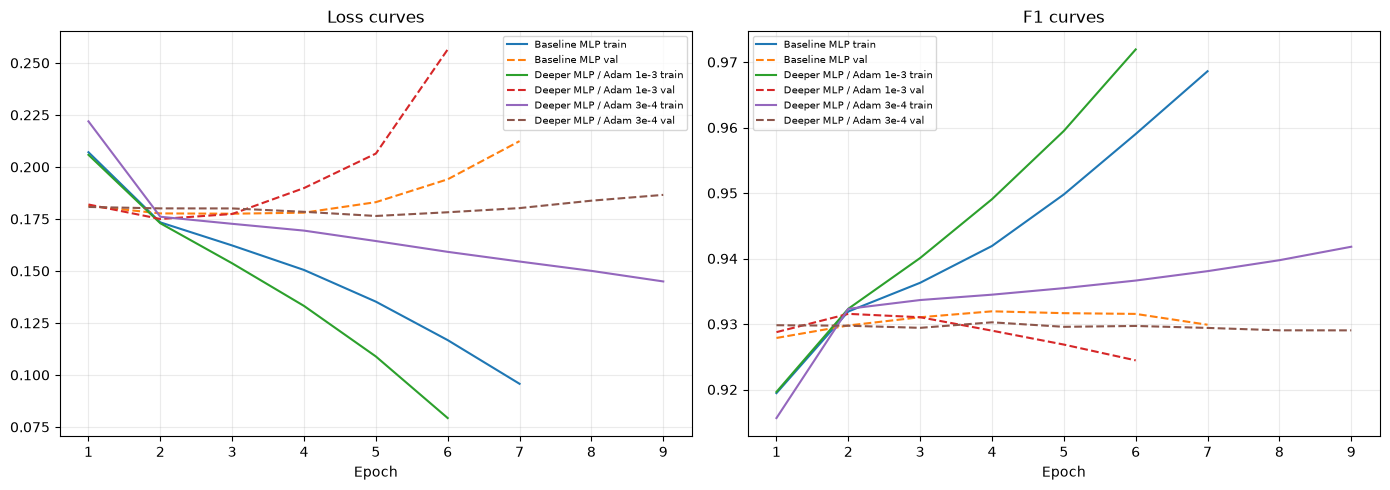

In [15]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
for name,h in mlp_histories.items(): axes[0].plot(h.epoch,h.train_loss,label=f"{name} train"); axes[0].plot(h.epoch,h.val_loss,"--",label=f"{name} val"); axes[1].plot(h.epoch,h.train_f1,label=f"{name} train"); axes[1].plot(h.epoch,h.val_f1,"--",label=f"{name} val")
axes[0].set(title="Loss curves",xlabel="Epoch"); axes[1].set(title="F1 curves",xlabel="Epoch");
for ax in axes: ax.legend(fontsize=7); ax.grid(alpha=.25)
plt.tight_layout(); save_figure(FIGURE_DIR/"mlp_training_curves.png",dpi=160,bbox_inches="tight"); plt.show()

### Phân tích hội tụ và overfitting

Cả ba giảm validation loss nhanh trong 2–5 epoch đầu rồi tăng trở lại, trong khi train loss tiếp tục giảm và train F1 tiếp tục tăng. Deeper `1e-3` rõ nhất: train F1 lên khoảng 0,972 nhưng validation F1 giảm từ 0,9316 ở epoch 2 xuống 0,9245 ở epoch 6. Baseline cũng giảm validation quality sau khoảng epoch 3.

Đây là bằng chứng overfitting rõ, không phải underfitting. Early stopping đã khôi phục checkpoint tốt nhất và ngăn tiếp tục đến 15 epoch. Learning rate `3e-4` làm diễn tiến chậm hơn nhưng không loại bỏ khoảng cách train–validation.

## Final test và error analysis

Deeper MLP / Adam `1e-3` được chọn hoàn toàn từ validation theo F1 rồi loss. Official test 200K chỉ được mở sau khi lựa chọn; kết quả test không được dùng để quay lại đổi architecture hoặc learning rate.

### So sánh bốn mô hình trên official test

Cell đánh giá ba baseline đã fit và final MLP trên cùng official-test subset, giữ training time từ giai đoạn fit. Bảng cho thấy hiệu quả dự đoán, complexity và learned-representation flag.

In [16]:
best_name=mlp_experiment_results.sort_values(["f1","loss"],ascending=[False,True]).iloc[0].experiment; final_mlp=mlp_models[best_name]; mlp_test=evaluate_mlp_classifier(final_mlp,test_loader,nn.CrossEntropyLoss()); test_rows=[]
for name,model in baseline_models.items(): pred=model.predict(X_test); test_rows.append({"model":name,"split":"official test","accuracy":accuracy_score(y_test,pred),"precision":precision_score(y_test,pred),"recall":recall_score(y_test,pred),"f1":f1_score(y_test,pred),"roc_auc":roc_auc_score(y_test,sklearn_score(model,X_test)),"training_seconds":baseline_val_results.set_index("model").loc[name,"training_seconds"],"parameter_count":np.nan,"learned_representation":False})
test_rows.append({"model":best_name,"split":"official test",**{k:mlp_test[k] for k in ["accuracy","precision","recall","f1","roc_auc"]},"training_seconds":mlp_experiment_results.set_index("experiment").loc[best_name,"training_seconds"],"parameter_count":count_trainable_parameters(final_mlp),"learned_representation":True})
model_comparison=pd.DataFrame(test_rows); model_comparison["input_representation"]="Sparse TF-IDF unigram+bigram"; model_comparison["interpretability"]=np.where(model_comparison.learned_representation,"Phân tán; cần probe","Coefficient/token likelihood"); display(Markdown(f"**Final MLP chọn bằng validation:** {best_name}")); display(model_comparison.sort_values("f1",ascending=False))

**Final MLP chọn bằng validation:** Deeper MLP / Adam 1e-3

,model,split,accuracy,precision,recall,f1,roc_auc,training_seconds,parameter_count,learned_representation,input_representation,interpretability
3,Deeper MLP / Adam 1e-3,official test,0.929695,0.927196,0.93262,0.929900,0.980112,1070.936768,1282210.0,True,Sparse TF-IDF unigram+bigram,Phân tán; cần probe
1,LinearSVC,official test,0.929135,0.928343,0.93006,0.929200,0.979002,42.209417,NaN,False,Sparse TF-IDF unigram+bigram,Coefficient/token likelihood
0,Logistic Regression,official test,0.928780,0.928369,0.92926,0.928814,0.978784,19.932224,NaN,False,Sparse TF-IDF unigram+bigram,Coefficient/token likelihood
2,ComplementNB,official test,0.884960,0.887486,0.88170,0.884584,0.954376,0.376000,NaN,False,Sparse TF-IDF unigram+bigram,Coefficient/token likelihood


### Kết quả four-model comparison

Final MLP đứng đầu: Accuracy **0,929695**, Precision 0,927196, Recall 0,932620, F1 **0,929900**, AUC **0,980112**. LinearSVC rất sát với F1 0,929200 và AUC 0,979002; Logistic Regression F1 0,928814; ComplementNB 0,884584.

So với LinearSVC, MLP chỉ hơn **0,000700 F1** (0,07 điểm phần trăm) và **0,001110 AUC**, nhưng train 1.070,94 s thay vì 42,21 s — khoảng **25,4 lần lâu hơn** — cùng hơn 1,28 triệu parameters và batch densification. Improvement có thật trên split này nhưng nhỏ về thực tiễn; LinearSVC là lựa chọn cost–performance cạnh tranh nhất. Assignment NN vẫn có ý nghĩa vì nó cho phép kiểm tra learned representation, không vì MLP bắt buộc phải thắng lớn.

### Confusion matrix, ROC và lỗi theo độ dài

Cell lấy logits final MLP, softmax thành positive score, vẽ confusion matrix/ROC và liệt kê các lỗi có score thấp nhất. `ConfusionMatrixDisplay.from_predictions(y_test,pred)` đặt hàng là true label, cột là predicted label.

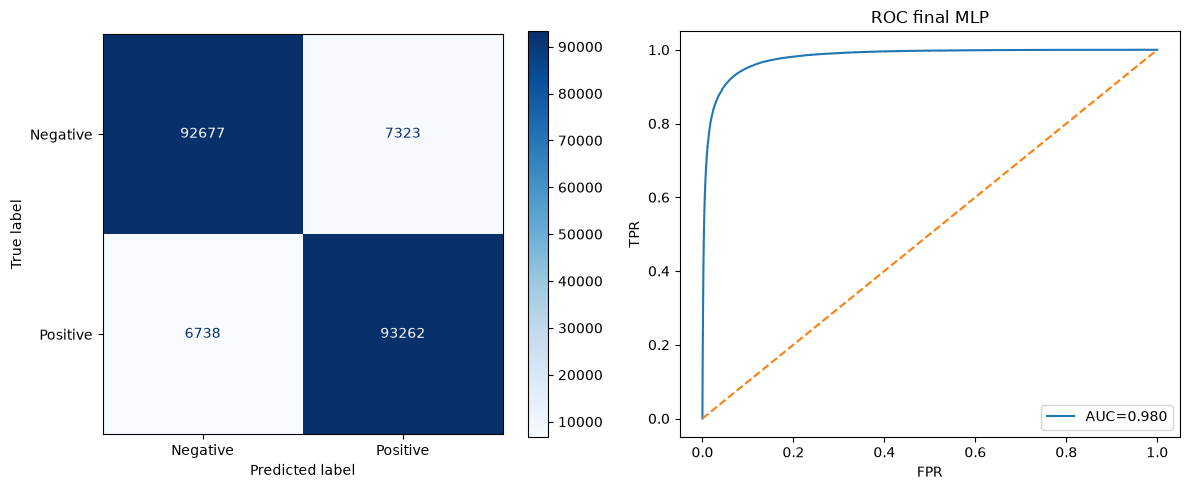

,text,label,prediction,positive_score,review_length
114399,Don't waste your time or money...: DO NOT BUY ...,1,0,0.000006,250
196707,It stinks: This book is the worst strategy gui...,1,0,0.000026,153
168378,lasts a few months: My daughter received this ...,1,0,0.000053,361
199972,BUMMER BURN OUT !: Bought this item for my kid...,1,0,0.000054,441
69565,Awful!!: Don't buy this controller. I just bou...,1,0,0.000086,366
71105,"Awful!! Bad graphics, movements! Don't waste y...",1,0,0.000096,589
239,Olympus smart media camera card: couldn't use ...,1,0,0.000248,269
103541,DO NOT BUY FROM SELLER apex_media. THIS GAME D...,1,0,0.000251,534
44019,waste of money!!!!!!!: I just bought this game...,1,0,0.000281,281
81142,Nice design poor quality of material: I don't ...,1,0,0.000289,182


,count,mean
review_length,,
"(98.999, 205.0]",40314,0.937590
"(205.0, 317.0]",39775,0.933074
"(317.0, 457.0]",40133,0.931702
"(457.0, 653.0]",39903,0.925745
"(653.0, 1015.0]",39875,0.920276


In [17]:
final_mlp.eval(); logits=[]
with torch.no_grad():
    for X_b,_ in test_loader: logits.append(final_mlp(X_b.to(device)).cpu())
logits=torch.cat(logits); score=torch.softmax(logits,1)[:,1].numpy(); pred=logits.argmax(1).numpy(); fig,axes=plt.subplots(1,2,figsize=(12,5)); metrics.ConfusionMatrixDisplay.from_predictions(y_test,pred,display_labels=["Negative","Positive"],cmap="Blues",ax=axes[0]); fpr,tpr,_=metrics.roc_curve(y_test,score); axes[1].plot(fpr,tpr,label=f"AUC={roc_auc_score(y_test,score):.3f}"); axes[1].plot([0,1],[0,1],"--"); axes[1].legend(); axes[1].set(title="ROC final MLP",xlabel="FPR",ylabel="TPR"); plt.tight_layout(); save_figure(FIGURE_DIR/"final_confusion_roc.png",dpi=160,bbox_inches="tight"); plt.show()
errors=test_df[["text","label"]].copy(); errors["prediction"]=pred; errors["positive_score"]=score; errors["review_length"]=errors.text.str.len(); display(errors[errors.label.ne(errors.prediction)].sort_values("positive_score").head(10)); display(errors.assign(correct=errors.label.eq(errors.prediction)).groupby(pd.qcut(errors.review_length,5,duplicates="drop"),observed=True).correct.agg(["count","mean"]))

### Phân tích final errors

Confusion matrix gồm **TN=92.677, FP=7.323, FN=6.738, TP=93.262**. FP là review Negative thật nhưng đoán Positive; FN là Positive thật nhưng đoán Negative. FP nhỉnh hơn FN, phù hợp precision (0,9272) thấp hơn recall (0,9326). ROC-AUC 0,9801 cho thấy ranking tốt nhưng không xóa khoảng 14.061 lỗi tại threshold hiện tại.

Accuracy giảm khá đều theo độ dài: từ **93,759%** ở nhóm ngắn nhất xuống **92,028%** ở nhóm dài nhất. Đây là pattern quan sát, không chứng minh review dài gây lỗi. Đáng chú ý, nhiều “FN” có target Positive nhưng text hiển thị rất tiêu cực như “DO NOT BUY”, “worst” hoặc “waste of money”; điều này phù hợp với khả năng label noise/source anomaly ở một số record, dù bảng 10 ví dụ không đủ định lượng toàn bộ lỗi hay chứng minh nguyên nhân duy nhất.

## Representation Probe và Linear Probe

Prepared TF-IDF là sparse 20K chiều nên dùng TruncatedSVD: phép chiếu này làm việc trực tiếp trên sparse matrix mà không center/densify toàn bộ. Hidden activation là dense 32 chiều của final MLP nên dùng PCA. Cả hai chỉ chiếu xuống 2D trên 10K test samples để trực quan hóa.

Linear probe dùng Logistic Regression fit trên train và đánh giá validation: một decoder giống nhau được đặt trên prepared TF-IDF và frozen hidden. MLP không được cập nhật trong probe.

### Trích hidden và tạo hai phép chiếu

Cell trích `H_train`, `H_val` theo sparse loader; final MLP sâu trả hidden cuối dimension 32. Với 10K test examples, TF-IDF dùng TruncatedSVD còn hidden dùng PCA, tô màu theo true sentiment. TruncatedSVD/PCA là công cụ projection, không phải neural representation mới.

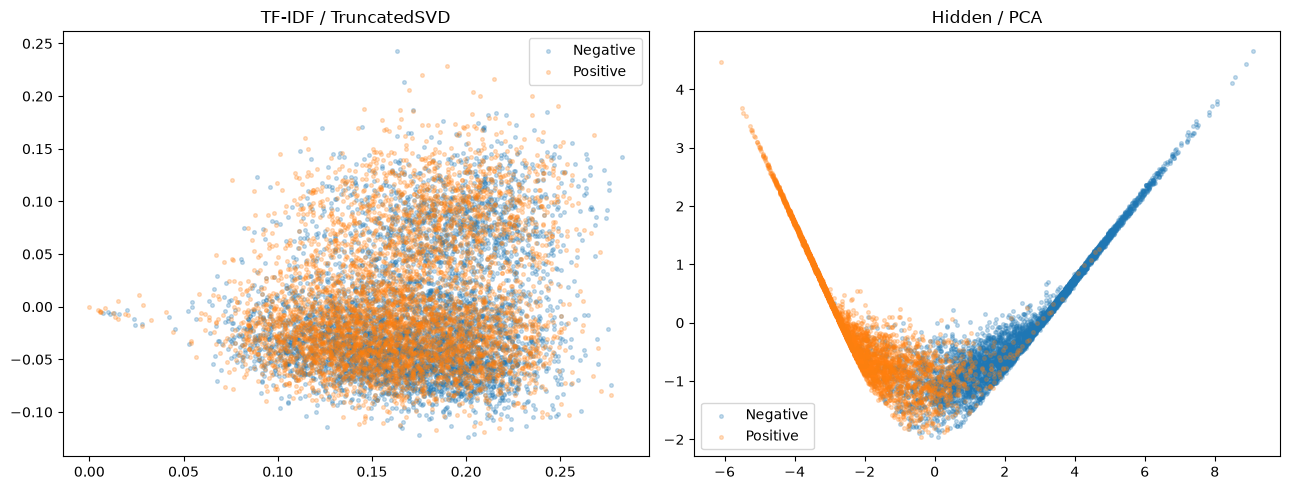

In [18]:
def extract_hidden_sparse(model,loader):
    model.eval(); out=[]
    with torch.no_grad():
        for X_b,_ in loader: out.append(model(X_b.to(device),return_hidden=True)[1].cpu().numpy())
    return np.vstack(out)
H_train=extract_hidden_sparse(final_mlp,train_eval_loader); H_val=extract_hidden_sparse(final_mlp,val_loader)
rng=np.random.default_rng(RANDOM_STATE); idx=rng.choice(X_test.shape[0],min(10_000,X_test.shape[0]),replace=False); X_probe=X_test[idx]; probe_loader=make_sparse_loader(X_probe,y_test[idx],False); H_probe=extract_hidden_sparse(final_mlp,probe_loader)
input_2d=TruncatedSVD(2,random_state=RANDOM_STATE).fit_transform(X_probe); hidden_2d=PCA(2,random_state=RANDOM_STATE).fit_transform(H_probe); fig,axes=plt.subplots(1,2,figsize=(13,5))
for label,color in [(0,"tab:blue"),(1,"tab:orange")]:
    mask=y_test[idx]==label; axes[0].scatter(input_2d[mask,0],input_2d[mask,1],s=7,alpha=.25,c=color,label=LABEL_NAME[label]); axes[1].scatter(hidden_2d[mask,0],hidden_2d[mask,1],s=7,alpha=.25,c=color,label=LABEL_NAME[label])
axes[0].set_title("TF-IDF / TruncatedSVD"); axes[1].set_title("Hidden / PCA");
for ax in axes: ax.legend()
plt.tight_layout(); save_figure(FIGURE_DIR/"tfidf_svd_vs_hidden_pca.png",dpi=160,bbox_inches="tight"); plt.show()

### Phân tích SVD/PCA thực tế

TF-IDF/SVD tạo một đám mây mà Negative và Positive chồng lấn gần như toàn bộ trong hai chiều đầu. Hidden/PCA có hình chữ V rõ: phần lớn Positive kéo về nhánh trái và Negative về nhánh phải, trong khi vùng đáy vẫn chồng lấn đáng kể. Hình học này phù hợp với việc MLP tổ chức lại feature theo target.

Tuy nhiên hai panel dùng hai phép chiếu khác nhau và chỉ giữ hai chiều. Overlap 2D không chứng minh full space không separable; tách đẹp cũng không chứng minh generalization. Held-out metrics và linear probe là bằng chứng chính.

### Linear probe trên prepared và frozen representation

Cell fit Logistic Regression riêng trên sparse TF-IDF train và dense hidden train, rồi chấm validation. Probe đo mức target có thể được linear decoder khai thác; nó không giải thích ý nghĩa semantic của từng neuron.

In [19]:
probe_rows=[]
for representation,A,B in [("Prepared TF-IDF",X_train,X_val),("Frozen hidden",H_train,H_val)]:
    probe=LogisticRegression(max_iter=300,random_state=RANDOM_STATE,n_jobs=-1).fit(A,y_train); prediction=probe.predict(B); score_probe=probe.predict_proba(B)[:,1]; probe_rows.append({"representation":representation,**classification_metrics(y_val,prediction,score_probe)})
probe_results=pd.DataFrame(probe_rows); display(probe_results)

,representation,accuracy,precision,recall,f1,roc_auc
0,Prepared TF-IDF,0.92920,0.93063,0.92754,0.929082,0.979052
1,Frozen hidden,0.93142,0.93643,0.92568,0.931024,0.980468


### Kết quả Linear Probe

Prepared TF-IDF probe đạt Accuracy 0,92920, F1 **0,929082**, AUC **0,979052**. Frozen-hidden probe đạt Accuracy 0,93142, Precision 0,93643, Recall 0,92568, F1 **0,931024**, AUC **0,980468**.

Hidden tăng khoảng **0,194 điểm phần trăm F1**, **0,222 điểm Accuracy** và **0,142 điểm AUC**, nhưng đổi lại recall giảm khoảng 0,186 điểm và precision tăng. Đây là evidence định lượng rằng learned representation dễ giải mã tuyến tính hơn một chút trên validation, không phải bằng chứng về semantic neuron hoặc ưu thế lớn, phổ quát.

## OPTIONAL — gradient norm, activation và seed stability

`RUN_OPTIONAL_DIAGNOSTICS=False` và `RUN_SEED_STABILITY=False`. Vì vậy notebook không có bằng chứng thực nghiệm về gradient distribution, dead activations hay độ ổn định qua seed; các phần này không được dùng trong kết luận.

### Diagnostic một batch

Nếu bật, cell sao chép final model, backpropagate một batch nhưng không update, rồi báo gradient norm và tỷ lệ activation bằng 0. Một batch chỉ là kiểm tra sức khỏe sơ bộ, không đủ kết luận vanishing/exploding gradient hoặc dead neurons.

In [20]:
if RUN_OPTIONAL_DIAGNOSTICS:
    diagnostic=copy.deepcopy(final_mlp).to(device).train(); X_b,y_b=next(iter(train_loader)); X_b,y_b=X_b.to(device),y_b.to(device); diagnostic.zero_grad(); output,hidden=diagnostic(X_b,return_hidden=True); nn.CrossEntropyLoss()(output,y_b).backward(); display(pd.DataFrame([{"parameter":n,"gradient_norm":p.grad.norm().item()} for n,p in diagnostic.named_parameters() if p.grad is not None])); print("Zero activation fraction:",(hidden==0).float().mean().item())
else: print("Bỏ qua diagnostics; bật RUN_OPTIONAL_DIAGNOSTICS nếu cần.")

Bỏ qua diagnostics; bật RUN_OPTIONAL_DIAGNOSTICS nếu cần.


### Trạng thái diagnostic thực tế

Output ghi “Bỏ qua diagnostics”, đúng với flag False. Không có số liệu gradient/activation để phân tích hoặc so giữa các mô hình.

### Lưu artifact FULL

Cell lưu bảng validation/test/history, state của final MLP, input/hidden/output dimensions, label map và fitted TF-IDF vectorizer. QUICK mode sẽ không ghi các artifact final.

In [21]:
if QUICK_MODE:
    print("QUICK_MODE: không lưu result/model artifact final.")
else:
    baseline_val_results.to_csv(RESULT_DIR/"comments_baseline_validation.csv",index=False); mlp_experiment_results.to_csv(RESULT_DIR/"comments_mlp_experiments.csv",index=False); model_comparison.to_csv(RESULT_DIR/"comments_model_comparison.csv",index=False); pd.concat([h.assign(experiment=n) for n,h in mlp_histories.items()],ignore_index=True).to_csv(RESULT_DIR/"comments_training_history.csv",index=False)
    torch.save({"model_state":final_mlp.state_dict(),"input_dim":d,"hidden_dims":list(final_mlp.hidden_dims),"output_dim":2,"label_map":LABEL_MAP,"experiment":best_name},MODEL_DIR/"final_mlp.pt"); joblib.dump(vectorizer,MODEL_DIR/"tfidf_vectorizer.joblib"); print("Đã lưu",RESULT_DIR)


Đã lưu E:\WINDOW\Project\intelligent-system-assignment-01\results\assignment03


### Artifact đã lưu

Output xác nhận kết quả được lưu vào `results/assignment03`. Khi inference phải tái sử dụng đúng vectorizer train, architecture và mapping 1/2→0/1; refit vocabulary hoặc đổi label map sẽ làm model không tương thích.

### Tóm tắt động từ kết quả test

Cell lấy model F1 cao nhất trong bảng test, traditional model tốt nhất và final MLP để sinh kết luận ngắn. Đây là summary tự động; phần Markdown kế tiếp bổ sung class balance, curves, confusion matrix, representation và limitations.

In [22]:
best=model_comparison.sort_values("f1",ascending=False).iloc[0]; mlp=model_comparison[model_comparison.learned_representation].iloc[0]; trad=model_comparison[~model_comparison.learned_representation].sort_values("f1",ascending=False).iloc[0]
display(Markdown(f"""## Kết luận dựa trên kết quả đã chạy

- Test F1 cao nhất: **{best['model']}**, F1={best['f1']:.4f}.
- Final MLP F1={mlp['f1']:.4f}; sparse traditional tốt nhất {trad['model']} F1={trad['f1']:.4f}.
- MLP train {mlp['training_seconds']:.1f}s với {int(mlp['parameter_count']):,} parameters.
- Kết luận cần kết hợp SVD/PCA, linear probe, loại lỗi review và cost; không mặc định MLP đáng dùng.
"""))

## Kết luận dựa trên kết quả đã chạy

- Test F1 cao nhất: **Deeper MLP / Adam 1e-3**, F1=0.9299.
- Final MLP F1=0.9299; sparse traditional tốt nhất LinearSVC F1=0.9292.
- MLP train 1070.9s với 1,282,210 parameters.
- Kết luận cần kết hợp SVD/PCA, linear probe, loại lỗi review và cost; không mặc định MLP đáng dùng.


### Kết luận thực nghiệm

Nguồn dữ liệu được cấu hình khoảng **3,6M train + 0,4M official test**; FULL experiment dùng **800K/100K/200K**, mỗi split cân bằng 50/50 do sampling. TF-IDF train-only tạo sparse matrices `(800K,20K)/(100K,20K)/(200K,20K)`, density train 0,411% và footprint 504,98 MiB.

Traditional validation tốt nhất là LinearSVC (F1 0,931211, AUC 0,979861, 42,21 s). Baseline MLP `20000→64→2` đạt validation F1 0,931036; Deeper `20000→64→32→2`, Adam `1e-3` đạt 0,931553 và được chọn; cùng mạng với `3e-4` chỉ đạt 0,929574 và tốn lâu hơn. Curves cho thấy overfitting sau best epoch; early stopping giữ Deeper checkpoint epoch 2.

Final MLP có **1.282.210 parameters**, batch 256, train **1.070,94 s**. Trên test: Accuracy 0,929695; Precision 0,927196; Recall 0,932620; F1 **0,929900**; AUC **0,980112**; confusion matrix `[[92677,7323],[6738,93262]]`. Nó hơn LinearSVC 0,07 điểm phần trăm F1 nhưng chậm khoảng 25,4 lần, nên lợi ích dự đoán nhỏ so với complexity tăng.

SVD của prepared TF-IDF chồng lấn mạnh; PCA hidden tạo hai nhánh class rõ hơn nhưng vẫn overlap. Frozen-hidden probe tăng F1 từ 0,929082 lên 0,931024 và AUC từ 0,979052 lên 0,980468: learned representation có tín hiệu hữu ích nhưng mức tăng nhỏ. Lỗi tăng ở review dài; một số lỗi confidence cao có text mâu thuẫn target, gợi ý label noise cần audit.

Giới hạn: dùng subset thay vì toàn bộ khoảng 4M reviews; balance do sampling; TF-IDF bag-of-ngrams/vocabulary 20K không nắm đầy đủ ngữ cảnh và word order; không pretrained embeddings/Transformer; chỉ hai kiến trúc và hai learning rate; một seed/split; CPU-only timing; không chạy seed stability/optional diagnostics; SVD/PCA 2D và linear probe không chứng minh generalization hoặc semantic meaning.

## Checklist sau lần chạy FULL

- [x] `QUICK_MODE=False`; seed 42; CPU được ghi nhận.
- [x] Official train/test tách biệt; modeling sizes 800K/100K/200K.
- [x] Mapping `1→0→Negative`, `2→1→Positive` được giữ nhất quán.
- [x] TF-IDF unigram+bigram 20K chỉ fit train; matrices giữ sparse.
- [x] MLP chỉ dense batch `[256,20000]`, không dense full matrix.
- [x] Ba traditional baseline và ba MLP đã chạy; final model chọn bằng validation.
- [x] Test, confusion matrix, error analysis, SVD/PCA và Linear Probe có output.
- [x] Artifact final đã lưu.
- [ ] Optional gradient/activation diagnostic và seed stability chưa chạy; kết luận không giả định các bằng chứng này.

**Kết luận ngắn:** Deeper MLP thắng F1/AUC test nhưng chỉ nhỉnh hơn LinearSVC rất ít với chi phí khoảng 25 lần; giá trị cốt lõi của A03 là quan sát được hidden representation học lại cấu trúc sentiment, không phải một chiến thắng lớn về metric.